In [1]:
import os
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
from keras.models import load_model

In [3]:
IMG_SIZE = 256
CHANNELS = 3

In [4]:
img_dir = "./data/images"
mask_dir = "./data/masks"
len(os.listdir(mask_dir))

2152

In [5]:
def load_data(img_dir, mask_dir):
    images = []
    masks = []
    
    image_files = os.listdir(img_dir)
    for img_file in image_files:
        base_name = os.path.splitext(img_file)[0]
        img_path = os.path.join(img_dir, img_file)

        for ext in ['.png', '.jpg', '.JPG']:    
            mask_path = os.path.join(mask_dir, base_name + ext)
            if os.path.exists(mask_path):
                break
        else:
            print(f"Mask not found for {img_file}")
            continue

        img = cv2.imread(img_path)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)) / 255

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE)) / 255
        mask = np.expand_dims(mask, axis=-1)

        images.append(img)
        masks.append(mask)

    return np.array(images), np.array(masks)

In [6]:
images , masks = load_data(img_dir, mask_dir)

In [7]:
len(masks)

2152

In [8]:
dataset = train_dataset = tf.data.Dataset.from_tensor_slices((images, masks))

In [9]:
for i, j in dataset.take(1):
    print(i.shape)

(256, 256, 3)


In [10]:
dataset = dataset.shuffle(buffer_size=100).batch(8).prefetch(tf.data.AUTOTUNE)

In [11]:
len(dataset)*8

2152

In [12]:
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    assert (train_split + test_split + val_split) == 1
    
    ds_size = len(ds)
    
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)
    
    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)
    
    train_ds = ds.take(train_size)    
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)
    
    return train_ds, val_ds, test_ds

In [13]:
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

In [14]:
for i, j in train_ds.take(1):
    print(i.shape)

(8, 256, 256, 3)


In [15]:
(len(train_ds)+len(test_ds)+len(val_ds))*8

2152

In [16]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

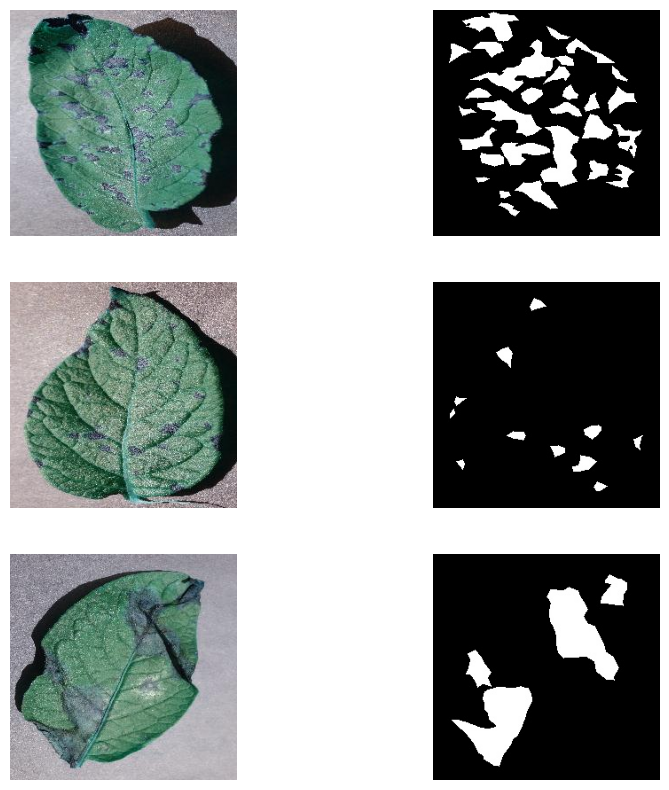

In [17]:
plt.figure(figsize=(10, 10))
for images, masks in train_ds.take(1):
    for i in range(3):  # show 3 samples from the batch
        plt.subplot(3, 2, 2*i + 1)
        plt.imshow(images[i])
        plt.axis('off')
        plt.subplot(3, 2, 2*i + 2)
        plt.imshow(masks[i].numpy().squeeze(), cmap='gray')
        plt.axis('off')


In [38]:
def build_unet(input_shape=(IMG_SIZE, IMG_SIZE, CHANNELS)):
    inputs = Input(input_shape)

    # Encoder
    c1 = Conv2D(16, 3, activation='relu', padding='same')(inputs)
    c1 = Conv2D(16, 3, activation='relu', padding='same')(c1)
    p1 = MaxPooling2D(pool_size=(2, 2))(c1)

    c2 = Conv2D(32, 3, activation='relu', padding='same')(p1)
    c2 = Conv2D(32, 3, activation='relu', padding='same')(c2)
    p2 = MaxPooling2D(pool_size=(2, 2))(c2)

    c3 = Conv2D(64, 3, activation='relu', padding='same')(p2)
    c3 = Conv2D(64, 3, activation='relu', padding='same')(c3)
    p3 = MaxPooling2D(pool_size=(2, 2))(c3)

    # Bottleneck
    b = Conv2D(128, 3, activation='relu', padding='same')(p3)
    b = Conv2D(128, 3, activation='relu', padding='same')(b)

    # Decoder
    u3 = UpSampling2D(size=(2, 2))(b)
    u3 = Concatenate()([u3, c3])
    c6 = Conv2D(64, 3, activation='relu', padding='same')(u3)
    c6 = Conv2D(64, 3, activation='relu', padding='same')(c6)

    u2 = UpSampling2D(size=(2, 2))(c6)
    u2 = Concatenate()([u2, c2])
    c7 = Conv2D(32, 3, activation='relu', padding='same')(u2)
    c7 = Conv2D(32, 3, activation='relu', padding='same')(c7)

    u1 = UpSampling2D(size=(2, 2))(c7)
    u1 = Concatenate()([u1, c1])
    c8 = Conv2D(16, 3, activation='relu', padding='same')(u1)
    c8 = Conv2D(16, 3, activation='relu', padding='same')(c8)

    # Output layer: 1 filter for binary mask, sigmoid for [0,1]
    outputs = Conv2D(1, 1, activation='sigmoid')(c8)

    model = Model(inputs=inputs, outputs=outputs)
    return model


In [39]:
model = build_unet()
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [40]:
history = model.fit(train_ds,
                    validation_data=val_ds,
                    batch_size=8,
                    epochs=10)

Epoch 1/10
215/215 ━━━━━━━━━━━━━━━━━━━━ 89s 405ms/step - accuracy: 0.8309 - loss: 0.3907 - val_accuracy: 0.8591 - val_loss: 0.2712
Epoch 2/10
215/215 ━━━━━━━━━━━━━━━━━━━━ 88s 410ms/step - accuracy: 0.8503 - loss: 0.2904 - val_accuracy: 0.8747 - val_loss: 0.2372
Epoch 3/10
215/215 ━━━━━━━━━━━━━━━━━━━━ 89s 413ms/step - accuracy: 0.8598 - loss: 0.2637 - val_accuracy: 0.8841 - val_loss: 0.2164
Epoch 4/10
215/215 ━━━━━━━━━━━━━━━━━━━━ 88s 410ms/step - accuracy: 0.8802 - loss: 0.2196 - val_accuracy: 0.8803 - val_loss: 0.2101
Epoch 5/10
215/215 ━━━━━━━━━━━━━━━━━━━━ 89s 414ms/step - accuracy: 0.8871 - loss: 0.2010 - val_accuracy: 0.8812 - val_loss: 0.2009
Epoch 6/10
215/215 ━━━━━━━━━━━━━━━━━━━━ 89s 412ms/step - accuracy: 0.8854 - loss: 0.2021 - val_accuracy: 0.9009 - val_loss: 0.1890
Epoch 7/10
215/215 ━━━━━━━━━━━━━━━━━━━━ 89s 415ms/step - accuracy: 0.8958 - loss: 0.1798 - val_accuracy: 0.9040 - val_loss: 0.1709
Epoch 8/10
215/215 ━━━━━━━━━━━━━━━━━━━━ 89s 412ms/step - accuracy: 0.8962 - loss: 0

In [41]:
model.save("./models/segmentation_model2.keras")


In [42]:
model.save("./models/segmentation_model2.h5")

In [69]:
acc = history.history['accuracy']
loss = history.history['loss']
val_accuracy = history.history['val_accuracy']
val_loss = history.history['val_loss']

Text(0.5, 1.0, 'val acc')

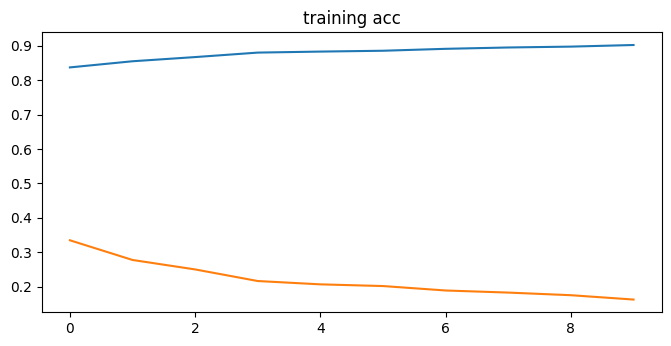

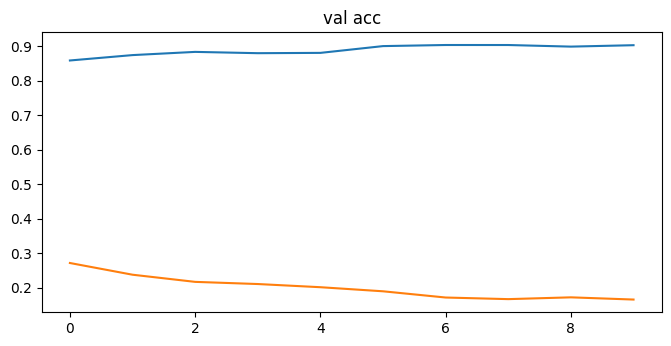

In [70]:
EPOCHS = 10

plt.figure(figsize=(8,8))
plt.subplot(2, 1, 1)
plt.plot(range(EPOCHS), acc, loss)
plt.title('training acc')

plt.figure(figsize=(8,8))
plt.subplot(2, 1, 2)
plt.plot(range(EPOCHS), val_accuracy, val_loss)
plt.title('val acc')

In [71]:
scores = model.evaluate(test_ds)

28/28 ━━━━━━━━━━━━━━━━━━━━ 11s 161ms/step - accuracy: 0.9122 - loss: 0.1477


In [72]:
scores

[0.15546394884586334, 0.9084883332252502]

In [73]:
preds = model.predict(test_ds)
preds[0]

28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 138ms/step


array([[[5.28829359e-03],
        [5.97387552e-04],
        [1.40968157e-04],
        ...,
        [7.04841077e-05],
        [7.38916220e-04],
        [1.92781130e-03]],

       [[2.10193498e-03],
        [3.23152548e-04],
        [1.57813352e-04],
        ...,
        [2.26751417e-05],
        [4.33844689e-04],
        [6.03834575e-04]],

       [[8.56169383e-04],
        [1.29876076e-04],
        [9.23218468e-05],
        ...,
        [1.13229544e-04],
        [3.31165502e-04],
        [7.03004538e-04]],

       ...,

       [[3.81416234e-04],
        [2.59078261e-05],
        [1.45965860e-05],
        ...,
        [5.07995937e-05],
        [1.15393843e-04],
        [9.28498106e-04]],

       [[1.15127221e-03],
        [7.60524199e-05],
        [3.77333708e-05],
        ...,
        [1.27087522e-04],
        [2.42303999e-04],
        [3.07427463e-03]],

       [[7.73399323e-03],
        [6.64377527e-04],
        [3.59416765e-04],
        ...,
        [6.87235035e-04],
        [1.8871

In [94]:
binary_mask = (preds[0] > 0.5).astype(np.uint8)
binary_mask

array([[[0],
        [0],
        [0],
        ...,
        [0],
        [0],
        [0]],

       [[0],
        [0],
        [0],
        ...,
        [0],
        [0],
        [0]],

       [[0],
        [0],
        [0],
        ...,
        [0],
        [0],
        [0]],

       ...,

       [[0],
        [0],
        [0],
        ...,
        [0],
        [0],
        [0]],

       [[0],
        [0],
        [0],
        ...,
        [0],
        [0],
        [0]],

       [[0],
        [0],
        [0],
        ...,
        [0],
        [0],
        [0]]], dtype=uint8)

In [85]:
def predict(model, img, mask):
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)
    predictions = model.predict(img_array)
    binary_mask = (predictions[0] > 0.5).astype(np.uint8)
    return binary_mask
    

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


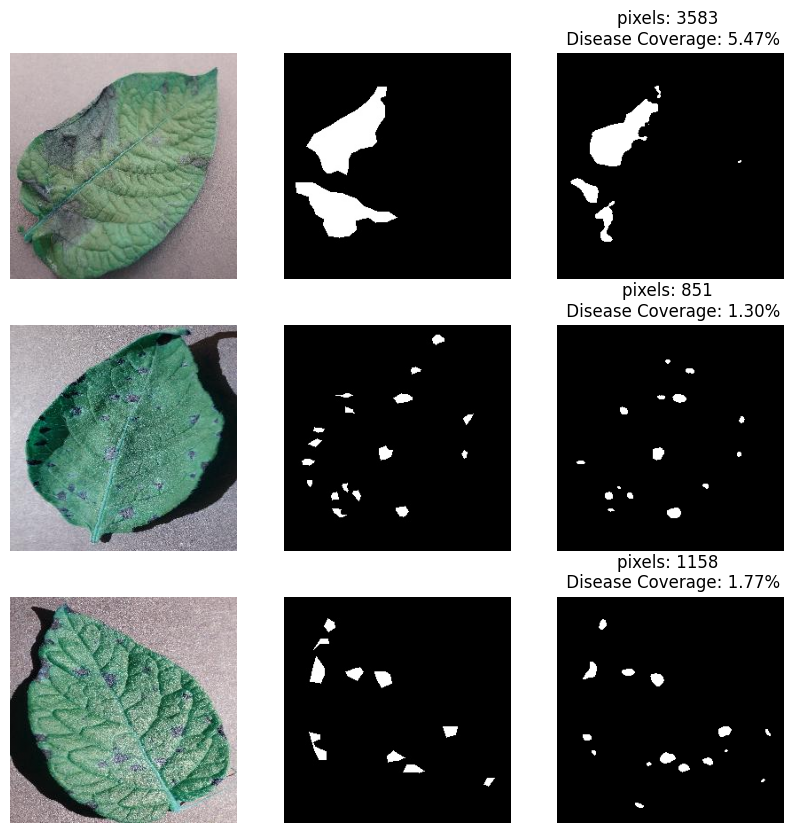

In [89]:
plt.figure(figsize=(10, 10))
for images, masks in test_ds.take(1):
    for i in range(3):
        binary_mask = predict(model, images[i], masks[i])
        binary_mask = binary_mask.squeeze() 
        plt.subplot(3, 3, 3*i + 1)
        plt.imshow(images[i])
        plt.axis('off')

        plt.subplot(3, 3, 3*i + 2)
        plt.imshow(masks[i], cmap='gray')
        plt.axis('off')
        
        plt.subplot(3, 3, 3*i + 3)
        plt.imshow(binary_mask, cmap='gray')
        plt.axis('off')
        diseased_pixels = np.sum(binary_mask == 1)
        total_pixels = binary_mask.size  # OR: binary_mask.shape[0] * binary_mask.shape[1]
        disease_coverage = (diseased_pixels / total_pixels) * 100
        plt.title(f"pixels: {diseased_pixels} \n Disease Coverage: {disease_coverage:.2f}%")


In [92]:
arr = np.array([[[0, 1, 1], [0, 0, 0], [1, 0, 0]]])
oness = np.sum(arr == 1)
oness
arr == 1

array([[[False,  True,  True],
        [False, False, False],
        [ True, False, False]]])

In [95]:
model.save("./models/segmentation_model3.keras")


In [41]:
model = load_model("./models/segmentation_model3.keras")

ValueError: File not found: filepath=./models/segmentation_model2.keras. Please ensure the file is an accessible `.keras` zip file.

In [16]:

# Fix: load and binarize the mask image first
mask_path = "./data/masks/0a6983a5-895e-4e68-9edb-88adf79211e9___RS_Early.B 9072.jpg"
image_path = "./data/images/0a6983a5-895e-4e68-9edb-88adf79211e9___RS_Early.B 9072.JPG"

# Load the grayscale mask
mask_image = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

# Check if loaded successfully
if mask_image is None:
    raise FileNotFoundError(f"Mask not found at: {mask_path}")

# Convert to binary mask
_, binary_mask = cv2.threshold(mask_image, 127, 255, cv2.THRESH_BINARY)
binary_mask = binary_mask // 255  # Normalize to 0 or 1

# Overlay function
def overlay_mask_opencv(image_path, mask):
    # Read the original image
    image = cv2.imread(image_path)
    if image is None:
        raise FileNotFoundError(f"Image not found at: {image_path}")

    image = cv2.resize(image, (mask.shape[1], mask.shape[0]))

    # Create a red color mask
    color_mask = np.zeros_like(image)
    color_mask[mask == 1] = [0, 0, 255]

    # Green for healthy (where mask == 0)
    color_mask[mask == 0] = [0, 127, 127]

    # Blend the image and mask
    alpha = 0.5
    overlaid = cv2.addWeighted(image, 1, color_mask, alpha, 0)

    return overlaid


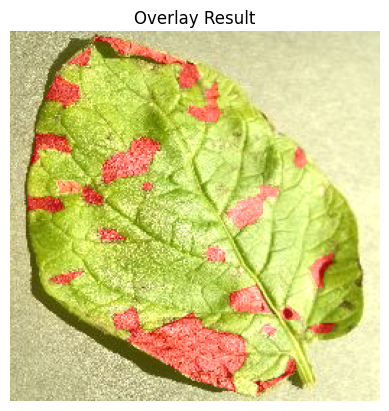

In [17]:
# Generate the overlayed image
result = overlay_mask_opencv(image_path, binary_mask)

# Display the result
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("Overlay Result")
plt.show()

In [66]:
model = load_model("../backend/models/segmentation_model3.keras")

In [67]:
r = model.evaluate(test_ds)
r

28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 140ms/step - accuracy: 0.9100 - loss: 0.1514


[0.15662018954753876, 0.9082151055335999]

In [91]:
from keras.utils import img_to_array, load_img

In [94]:
image_path = "./data/images/0a6983a5-895e-4e68-9edb-88adf79211e9___RS_Early.B 9072.JPG"
img = cv2.imread(image_path)
img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
img = img / 255.0  # Normalize exactly like training
img = np.expand_dims(img, axis=0)

pred = model.predict(img)
binary_mask = (pred[0, :, :, 0] > 0.5).astype(np.uint8)  # Threshold

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


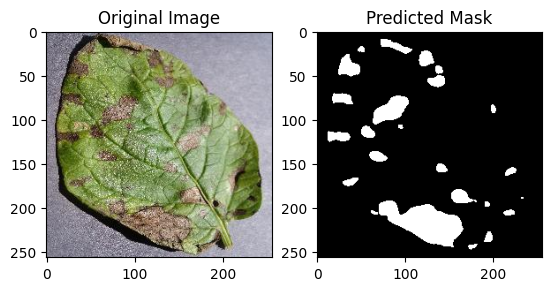

In [95]:
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB))
plt.title("Original Image")

plt.subplot(1, 2, 2)
plt.imshow(binary_mask, cmap='gray')
plt.title("Predicted Mask")
plt.show()


In [100]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def overlay_mask(image, mask, alpha=0.5):
    """
    Overlay predicted binary mask on the original image.
    
    Args:
        image (numpy array): Original RGB image (H x W x 3)
        mask (numpy array): Binary mask (H x W) with values 0 or 1
        alpha (float): Transparency for overlay
    
    Returns:
        overlaid (numpy array): Image with red mask overlay
    """
    # Ensure image is uint8 (0-255)
    if image.max() <= 1.0:
        image = (image * 255).astype(np.uint8)

    # Create 3-channel color mask: red for disease
    image = image.squeeze()
    color_mask = np.zeros_like(image)
    color_mask[mask == 1] = [255, 0, 0]  # Red for diseased area

    # Overlay using alpha blending
    overlaid = cv2.addWeighted(image, 1.0, color_mask, alpha, 0)

    return overlaid


TypeError: Invalid shape (1, 256, 256, 3) for image data

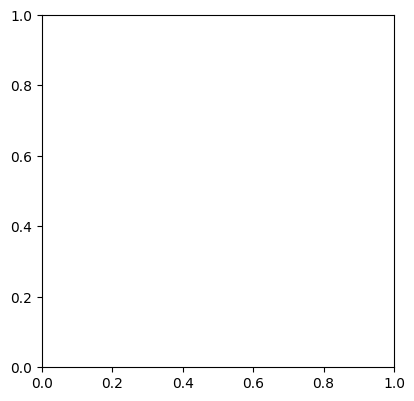

In [102]:
# image shape: (H, W, 3), RGB
# predicted_mask shape: (H, W), values: 0 or 1

overlaid = overlay_mask(img, binary_mask)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(overlaid)
plt.title("Overlay with Prediction")
plt.axis("off")

plt.tight_layout()
plt.show()
